### Simple Linear Regression 

In [56]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline

In [57]:
# Read the Dataset
df = pd.read_csv('height-weight.csv')

In [58]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

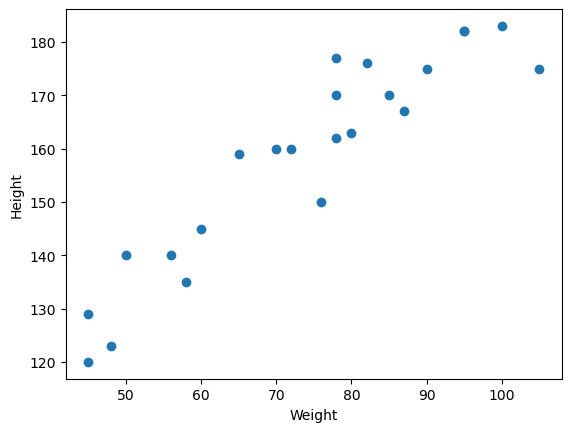

In [59]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [60]:
# Divide dataset into independent and dependent feature
X = df[['Weight']] # Independent feature
y = df['Height'] # Dependent feature

In [61]:
X.head()
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [62]:
# Train test split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
#X_train is my input feature , y_train is my output feature for training dataset
# for testing our model we use x_test,y_test 
# 0.20 is 20% of datapoint in x is consider as a test data 

In [63]:
X.shape

(23, 1)

In [64]:
X_train.shape, X_test.shape,y_train.shape,y_test.shape

((17, 1), (6, 1), (17,), (6,))

In [65]:
# Standardized the Dataset Train independent data
from sklearn.preprocessing import StandardScaler
#StandardScaler is nothing but applying Z-score

In [66]:
scaler = StandardScaler()

In [67]:
X_train.head()

,Weight
1,58
13,100
5,78
2,48
11,95


In [68]:
X_train = scaler.fit_transform(X_train) # fit - mean,standard deviation , transform - Z score
X_test = scaler.transform(X_test)

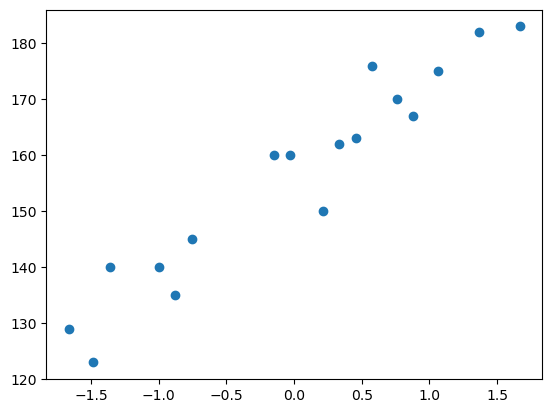

In [70]:
plt.scatter(X_train,y_train)

In [71]:
# Train the Simple Liner Regression Model
from sklearn.linear_model import LinearRegression


In [72]:
regressor = LinearRegression()

In [73]:
regressor.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
print(f'The Slope or coefficient of weight is - ',regressor.coef_)
print(f'Intercept:',regressor.intercept_)

The Slope or coefficient of weight is -  [17.2982057]
Intercept: 156.47058823529412


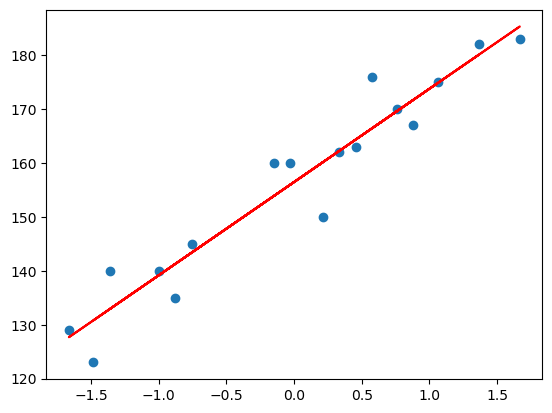

In [79]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

### Prediction of train data 
1. Predicted height output = intercept + coef_(Weights)
2. y_pred_train = 156.4705882 + 17.29(X_train)
### Prediction of test data 
1. predicted height output = intercept + coef_(Weights)
2. y_pred_train = 156.4705882 + 17.29(X_test)

In [86]:
y_pred_test = regressor.predict(X_test)

In [88]:
y_pred_test,y_test

(array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
        148.64197186, 190.55897293]),
 15    177
 9     170
 0     120
 8     182
 17    159
 12    175
 Name: Height, dtype: int64)

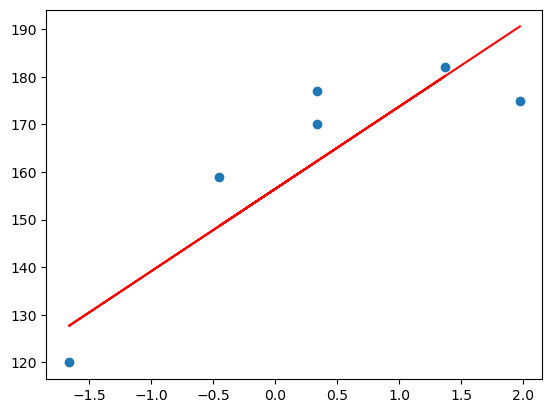

In [89]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

### Performance Matrics
- MSE,MAE,RMSE
- R Score and Adjusted R Score

In [91]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [98]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


### R square formula
R^2 = 1 - SSR/SST
R^2 = coefficient of determination SSR = sum of squares of residuals, SST = total sum of squares

In [102]:
# how much acuracy of our model is we calculate R2 score 
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)

In [103]:
score

0.7360826717981276

## Adjusted R square
**Adjusted R^2 = 1 - [(1-R^2)*(n-1)/(n-k-1)]**

where: 

R^2 : The R^2 of the model

n: The number of observations

k: The number of predictor variables

In [ ]:
# Display Adjusted R-Squared 
1 - (1-score)*(len(y_test)-1)/(len(y_test) - X_test.shape[1]-1)

### R^2 VALUE is greater than Adjusted R^2 value

In [105]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [106]:
# New data point weight is 80
scaler_weight = scaler.transform([80])
scaler_weight

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.45613165]])

In [111]:
scaler_weight[0]

array([0.45613165])

In [114]:
print("The height prediction for weight 80kg is:",regressor.predict(scaler_weight))

The height prediction for weight 80kg is: [164.36084726]


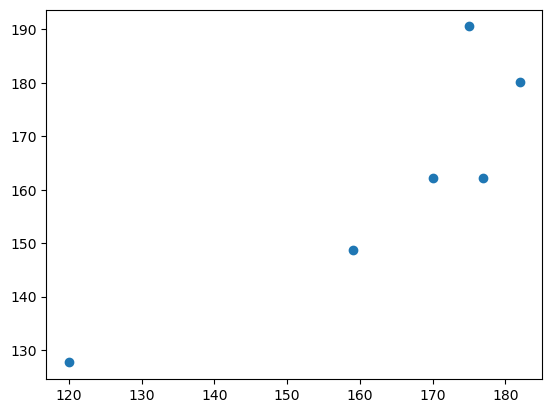

In [115]:
## Below all the Assumption - 
## 1 Plot a scatter plot for the prediction 
plt.scatter(y_test,y_pred_test)

In [116]:
## 2. Residuals 
residuals = y_test - y_pred_test
residuals

15    14.735003
9      7.735003
0     -7.683471
8      1.920277
17    10.358028
12   -15.558973
Name: Height, dtype: float64

C:\Users\Dell\AppData\Local\Temp\ipykernel_31676\159809471.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde = True)


<Axes: xlabel='Height', ylabel='Density'>

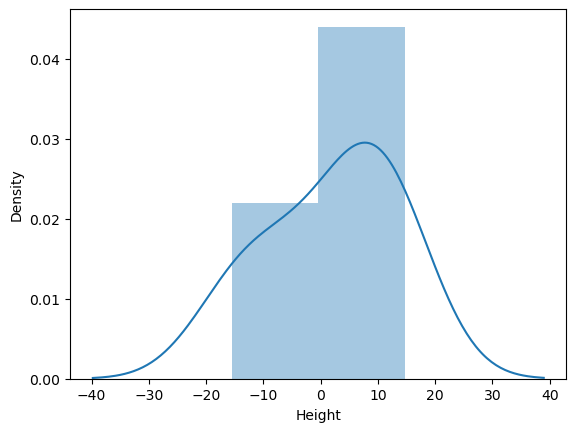

In [119]:
# plot the Residuals
import seaborn as sns
sns.distplot(residuals,kde = True)

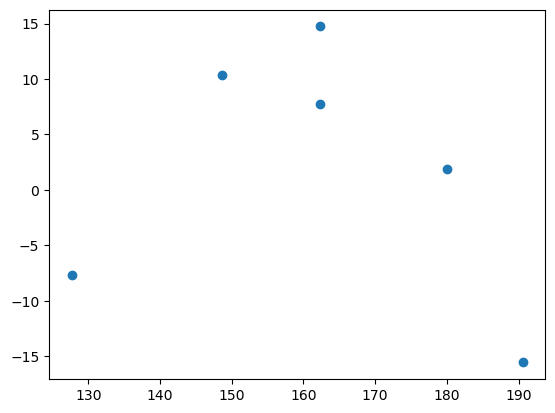

In [120]:
## Scatter plot wrt pcrediction and residuals
# uniform distribution 
plt.scatter(y_pred_test,residuals)
